# Customer Churn & Retention Analysis

## 1. Project Overview

This project analyses customer churn data from a telecommunications company to identify the characteristics associated with customers leaving the company. The analysis uses Python and Pandas for data cleaning, exploratory analysis and customer segmentation, with Matplotlib used to visualise key churn patterns.

The goal is to identify high-risk customer segments and translate the findings into practical business recommendations that could support customer retention strategies.

## 2. Business Problem

Customer churn is a major challenge for telecommunications companies because losing existing customers can reduce recurring revenue and increase the need to acquire replacement customers.

The company wants to better understand which customers are most likely to leave and which customer characteristics are associated with higher churn.

This analysis aims to identify patterns in customer contracts, tenure, internet services, monthly charges, technical support and payment methods that are associated with customer churn. The findings will help identify high-risk customer segments and support more targeted customer retention strategies.

## 3. Project Objectives

The main objective of this project is to analyse customer churn and identify the characteristics associated with customers leaving the telecommunications company.

The analysis aims to:

- Calculate the overall customer churn rate.
- Analyse how contract type is associated with customer churn.
- Examine the relationship between customer tenure and churn.
- Compare churn rates across different internet service types.
- Investigate the relationship between monthly charges and churn.
- Examine whether technical support is associated with customer retention.
- Analyse churn across different payment methods.
- Identify customer segments with particularly high churn rates.
- Develop an exploratory risk score to group customers based on multiple churn-associated characteristics.
- Provide data-driven business recommendations that could support customer retention strategies.

## 4. Import Libraries

In [1]:
# Let's import tools for this project such as:

import pandas as pd
import matplotlib.pyplot as plt

## 5. Load and Understand the Data

The dataset contains customer information from a telecommunications company, including customer demographics, account details, services, contract information, charges and churn status.

Before cleaning and analysing the data, the dataset is loaded and inspected to understand its structure, size, columns and data types.

In [2]:
# loading data
df = pd.read_csv('.../data/Telco-Customer-Churn.csv')

In [3]:
# viewing records

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
# checking dataset size

df.shape

(7043, 21)

In [6]:
# identifying variables

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
# checking data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The initial inspection shows that the dataset includes both numerical and categorical variables. Customer tenure ranges from 0 to 72 months, while monthly charges vary considerably across customers.

Further data cleaning is required before analysis, particularly for the `TotalCharges` column, which requires conversion to a numeric data type.

## 6. Data Cleaning

Before performing the churn analysis, the dataset was checked for duplicate records, missing values and incorrect data types. Particular attention was given to the `TotalCharges` column, which was initially stored as text rather than a numeric variable.

In [9]:
# Check duplicate customers

df.duplicated().sum()

np.int64(0)

No duplicate customer records were identified in the dataset.

In [10]:
# Check for blank values

(df == "").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
# Investigate TotalCharges

df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


The `TotalCharges` column contained 11 blank values represented as whitespace. Further inspection showed that these customers had a tenure of 0 months, indicating that they were new customers who had not yet accumulated total charges.

### We need TotalCharges to be numeric so we can calculate things like:

Average total charges
Revenue by customer group
Churn vs. spending
Customer lifetime value patterns

### We'll convert the blank values to NaN, then convert the column to numbers.

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
# Check

df["TotalCharges"].isna().sum()

np.int64(11)

`TotalCharges` was converted from an object data type to numeric. The 11 blank values were converted to missing values (`NaN`).

These records were retained because they represent valid customers with zero months of tenure rather than duplicate or invalid customer records. The missing `TotalCharges` values were therefore left as `NaN` rather than removing the customers or assigning an estimated value.

In [14]:
# To check the affected customers

df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


After cleaning, the dataset retained all 7,043 customer records. No duplicate records were found, and `TotalCharges` was successfully converted to a numeric data type. The dataset is now ready for exploratory analysis.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## 7. Exploratory Data Analysis

Exploratory data analysis was performed to understand the overall distribution of customer churn and establish a baseline before investigating the factors associated with customers leaving the company.

## Business Question #1:

How many customers have churned, and what percentage of customers have churned?

In [17]:
# This tells us the number of customers in each group.

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
# This tells us the percentage.

df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

The first important business finding.

Business interpretation

Our overall churn rate is 26.54%.

That means roughly 1 in every 4 customers has churned.

This gives us our baseline. The next question is much more useful:

Which types of customers are most likely to churn?

We're going to start with one of the most important variables in this dataset: Contract.

Why this matters?

This becomes our baseline churn rate.

Later, we'll compare it against things like:

Contract type
Tenure
Internet service
Monthly charges
Payment method
Tech support
Senior citizen status

For example, we'll eventually be able to answer questions like:

"Customers on month-to-month contracts churn at a much higher rate than customers on two-year contracts."

## 8. Customer Churn Analysis

This section examines how different customer characteristics, services and account features are associated with customer churn.

### 8.1 Contract Type and Churn

In [19]:
# Churn by contract type
# This shows the churn percentage within each contract type.

pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


There is a very large difference in churn by contract type:

Month-to-month: 42.71% churn

One-year: 11.27% churn

Two-year: 2.83% churn

So customers on month-to-month contracts are by far the highest-risk group.

📌 Business Insight:

Customers on month-to-month contracts have substantially higher churn than customers on longer-term contracts, with a 42.71% churn rate compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

⚠️ One important analyst point: we shouldn't say that longer contracts cause lower churn. Our analysis shows a strong relationship, but it doesn't prove causation.

### 8.2 Customer Tenure and Churn

In [20]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

In [21]:
tenure_churn = (
    df.groupby("tenure_group", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn.round(2)

tenure_group
0-12 months     47.44
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64

📌 Business Insight:

Customer churn is highest during the first 12 months, at 47.44%, and declines substantially as customer tenure increases. The churn rate falls to 28.71% for customers with 13–24 months of tenure, 20.39% for those with 25–48 months, and just 9.51% for customers with 49–72 months of tenure.

### 8.3 Internet Service and Churn

The churn rate was compared across different internet service types to determine whether customer churn varies between DSL, fiber optic and customers without internet service.

In [22]:
# Churn by Internet Service
# Next, let's investigate:
# Does the type of internet service a customer uses relate to churn?

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


The standout group is Fiber optic customers, with a churn rate of 41.89%. That's more than twice the churn rate among DSL customers (18.96%). Customers without internet service have the lowest churn rate at 7.40%.

📌 Business Insight:

Fiber optic customers have the highest churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service. This identifies fiber optic customers as an important segment for further investigation and potential retention efforts.

Notice the wording "further investigation." We shouldn't conclude that fiber optic service itself causes churn. For example, fiber customers might also have higher monthly charges or be more likely to have month-to-month contracts. We'll investigate those possibilities.

So far, a pattern is developing: month-to-month customers, newer customers, and fiber optic customers appear to be higher-risk groups.

### 8.4 Monthly Charges and Churn

Monthly charges were compared between customers who churned and customers who remained with the company to determine whether customer costs are associated with churn.

In [23]:
# Monthly charges and churn
# Now let's test whether customers who churn are paying more each month.

df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


| Churn | Customers | Mean monthly charge | Median monthly charge |
| ----- | --------: | ------------------: | --------------------: |
| No    |     5,174 |              $61.27 |                $64.43 |
| Yes   |     1,869 |              $74.44 |                $79.65 | 

Customers who churned paid, on average, $13.17 more per month than customers who stayed:

$74.44 − $61.27 = $13.17

That's about 21.5% higher than the average monthly charge of customers who stayed.

📌 Business Insight:

Customers who churned had higher monthly charges, averaging $74.44 compared with $61.27 for customers who remained. This suggests that higher monthly costs may be associated with increased churn risk.

Again, we shouldn't say higher prices caused churn. We're identifying an association.

This is becoming particularly interesting when combined with our previous result: fiber optic customers had 41.89% churn. One useful question is whether fiber customers also tend to pay higher monthly charges.

In [24]:
# Compare charges by internet service
# This is where we start connecting findings together, rather than analysing every column independently.

df.groupby("InternetService")["MonthlyCharges"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
InternetService,,,
DSL,2421,58.10,56.15
Fiber optic,3096,91.50,91.68
No,1526,21.08,20.15


## Monthly charges by internet service

| Internet service | Customers | Average monthly charge |     Median |
| ---------------- | --------: | ---------------------: | ---------: |
| DSL              |     2,421 |                 $58.10 |     $56.15 |
| Fiber optic      |     3,096 |                 $91.50 |     $91.68 |
| No internet      |     1,526 |                 $21.08 |     $20.15 |

### Remember our earlier churn rates:

Fiber optic → 41.89% churn
DSL → 18.96% churn
No internet → 7.40% churn

Now we can see that fiber-optic customers also have by far the highest monthly charges, averaging $91.50.

📌 Business Insight:

Fiber optic customers have both the highest average monthly charge ($91.50) and the highest churn rate (41.89%). This suggests that the high churn observed among fiber optic customers may be associated with higher customer costs, although further analysis is needed before attributing churn to price.

### 8.5 Tech Support and Churn

Customer churn was compared across technical support categories to examine whether access to tech support is associated with customer retention.

In [25]:
# Let's investigate Tech Support
# Now let's ask:
# Are customers without tech support more likely to churn?

pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Among customers with internet service, those without tech support have a 41.64% churn rate, compared with only 15.17% for customers with tech support.

That's a difference of about 26.47 percentage points.

📌 Business Insight:

Customers without tech support have a substantially higher churn rate (41.64%) than customers with tech support (15.17%). This suggests that access to support services is associated with stronger customer retention.

Customers classified as "No internet service" have a churn rate of 7.40%, but this group is structurally different because these customers do not use an internet service and therefore would not require internet-related technical support.

Among customers using internet services, the results suggest that access to tech support is associated with stronger customer retention. However, the analysis demonstrates an association and does not establish that tech support directly causes lower churn.

Notice that we're not saying "lack of tech support causes churn." There could be other differences between these customers.

We're now developing a useful picture of the high-risk customer: short tenure + month-to-month contract + fiber optic + higher monthly charges + no tech support.

### 8.6 Payment Method and Churn

Customer churn was analysed across different payment methods to determine whether particular payment methods are associated with higher customer churn.

In [26]:
# Investigate payment method
# There's one more customer-behaviour variable worth investigating before we start visualising our findings:
# Does payment method relate to customer churn?

# This time we're combining segment size + number churned + churn rate + average monthly charge in one analysis.

payment_churn = (
    df.groupby("PaymentMethod")
      .agg(
          Customers=("customerID", "count"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100),
          Avg_Monthly_Charge=("MonthlyCharges", "mean")
      )
      .reset_index()
)

payment_churn["Churn_Rate"] = payment_churn["Churn_Rate"].round(2)
payment_churn["Avg_Monthly_Charge"] = payment_churn["Avg_Monthly_Charge"].round(2)

payment_churn.sort_values("Churn_Rate", ascending=False)

,PaymentMethod,Customers,Churned,Churn_Rate,Avg_Monthly_Charge
2,Electronic check,2365,1071,45.29,76.26
3,Mailed check,1612,308,19.11,43.92
0,Bank transfer (automatic),1544,258,16.71,67.19
1,Credit card (automatic),1522,232,15.24,66.51


## Payment method and churn

The standout finding is electronic check. Nearly half of those customers churned.

Also notice something interesting: automatic bank transfer and automatic credit card have much lower churn rates, around 15–17%.

📌 Business Insight:

Customers paying by electronic check have the highest churn rate at 45.29%, compared with 15.24% for automatic credit-card payments and 16.71% for automatic bank transfers. Electronic-check customers also have relatively high average monthly charges ($76.26), making this an important segment for further investigation.

We shouldn't conclude that electronic checks cause churn. For example, electronic-check customers could disproportionately be month-to-month customers.

Now we have enough exploratory findings

We've identified several important churn patterns: overall churn is 26.54%, while elevated churn appears among month-to-month contracts (42.71%), 0–12 month tenure (47.44%), fiber optic customers (41.89%), customers without tech support (41.64%), and electronic-check customers (45.29%). Our combined analysis found an especially important segment: month-to-month + no tech support = 50.37% churn (1,350 of 2,680 customers).

### 8.7 Contract Type and Tech Support

Contract type and tech support were analysed together to identify customer segments with particularly high churn rates. Combining multiple customer characteristics can provide a clearer picture of churn risk than examining each factor independently.

In [27]:
### 8.7.2 Analyse contract and tech support together

contract_support = (
    df.groupby(["Contract", "TechSupport"])
      .agg(
          Customers=("customerID", "count"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
      )
      .reset_index()
)

contract_support["Churn_Rate"] = contract_support["Churn_Rate"].round(2)

contract_support.sort_values("Churn_Rate", ascending=False)

,Contract,TechSupport,Customers,Churned,Churn_Rate
0,Month-to-month,No,2680,1350,50.37
2,Month-to-month,Yes,671,206,30.70
1,Month-to-month,No internet service,524,99,18.89
3,One year,No,557,82,14.72
5,One year,Yes,552,75,13.59
6,Two year,No,236,14,5.93
8,Two year,Yes,821,29,3.53
4,One year,No internet service,364,9,2.47
7,Two year,No internet service,638,5,0.78


**Insight:** Month-to-month customers without tech support represent a particularly high-risk customer segment. Of the 2,680 customers in this group, 1,350 churned, resulting in a churn rate of 50.37%.

Month-to-month customers with tech support also experienced relatively high churn at 30.70%, although this was considerably lower than the 50.37% observed among month-to-month customers without tech support.

Churn was substantially lower among customers on one-year and two-year contracts, regardless of tech-support status.

These findings suggest that month-to-month customers without tech support could be an important segment for targeted retention efforts. However, the relationships are associative and should not be interpreted as evidence that changing contract type or adding tech support would directly prevent churn.

## 9. Customer Risk Segmentation

The previous analysis identified several customer characteristics associated with higher churn. To examine how these characteristics interact, an exploratory risk score was created.

Customers receive one risk point for each of the following characteristics:

- Month-to-month contract
- Tenure of 12 months or less
- Fiber optic internet service
- No tech support
- Electronic check payment method

The resulting risk score ranges from 0 to 5, with higher scores representing customers who have more churn-associated characteristics.

This score is designed as an exploratory segmentation tool rather than a predictive machine-learning model.

In [28]:
### 9.2 Create the risk score

df["risk_score"] = 0

df.loc[df["Contract"] == "Month-to-month", "risk_score"] += 1
df.loc[df["tenure"] <= 12, "risk_score"] += 1
df.loc[df["InternetService"] == "Fiber optic", "risk_score"] += 1
df.loc[df["TechSupport"] == "No", "risk_score"] += 1
df.loc[df["PaymentMethod"] == "Electronic check", "risk_score"] += 1

In [29]:
### Then check how many customers have each score:

df["risk_score"].value_counts().sort_index()

risk_score
0    1539
1    1186
2    1390
3    1272
4    1067
5     589
Name: count, dtype: int64

In [30]:
### 9.3 Calculate churn by risk score

risk_analysis = (
    df.groupby("risk_score")
      .agg(
          Customers=("customerID", "count"),
          Churned=("Churn", lambda x: (x == "Yes").sum()),
          Churn_Rate=("Churn", lambda x: (x == "Yes").mean() * 100)
      )
      .reset_index()
)

risk_analysis["Churn_Rate"] = risk_analysis["Churn_Rate"].round(2)

risk_analysis

,risk_score,Customers,Churned,Churn_Rate
0,0,1539,39,2.53
1,1,1186,87,7.34
2,2,1390,264,18.99
3,3,1272,451,35.46
4,4,1067,602,56.42
5,5,589,426,72.33


### Risk Segmentation Insight

Churn increases substantially as customers accumulate more of the identified risk characteristics.

Customers with a risk score of 0 have an observed churn rate of only 2.53%. The churn rate increases to 18.99% at a score of 2, 35.46% at a score of 3, 56.42% at a score of 4, and 72.33% among customers with all five identified risk characteristics.

This demonstrates that combining multiple customer characteristics provides a clearer way to identify high-risk customer segments than examining individual factors in isolation.

Customers with higher risk scores could therefore be prioritised for further investigation and targeted retention initiatives.

### Risk Score Limitation

The customer risk score is an exploratory rule-based segmentation method and should not be interpreted as a predictive model.

The risk characteristics were selected based on patterns observed within the same dataset used to evaluate the score. Therefore, the 72.33% churn rate among customers with a score of 5 does not represent predictive accuracy for new customers.

Before using this approach for operational decision-making, the risk factors should be validated on unseen data or evaluated using an appropriate predictive modelling approach.

## 10. Data Visualisation

Visualisations were created to communicate the most important churn patterns identified during the analysis. The charts focus on contract type, customer tenure, internet service and the exploratory customer risk score.

### 10.1 Churn Rate by Contract Type

This visual compares churn rates across the three customer contract types.

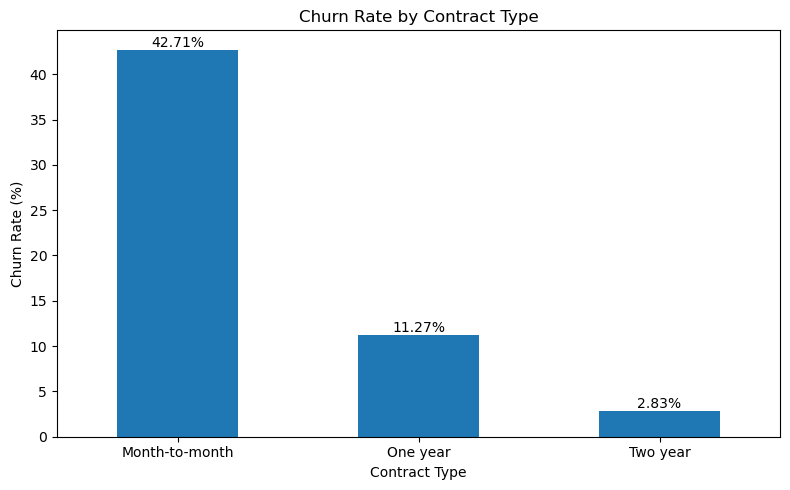

In [31]:
contract_churn_plot = (
    df.groupby("Contract")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ax = contract_churn_plot.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### 10.2 Churn Rate by Customer Tenure

This visual shows how customer churn changes as customer tenure increases.

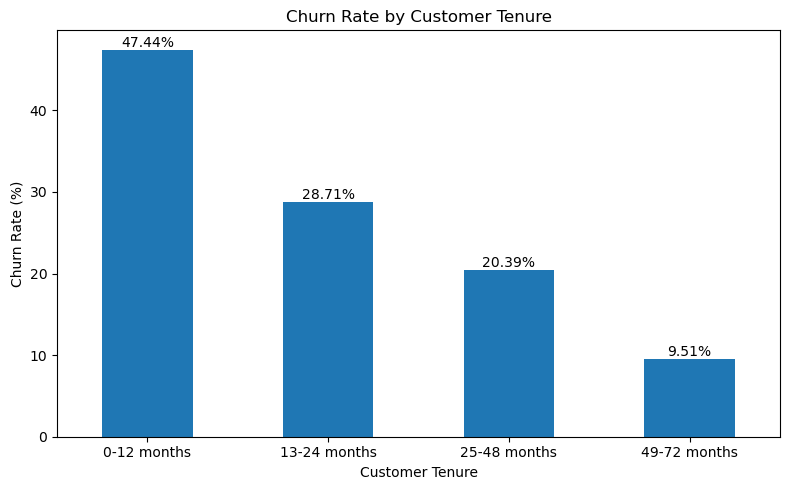

In [32]:
tenure_churn_plot = (
    df.groupby("tenure_group", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))
ax = tenure_churn_plot.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### 10.3 Churn Rate by Internet Service

This visual compares churn rates across the different internet service categories.

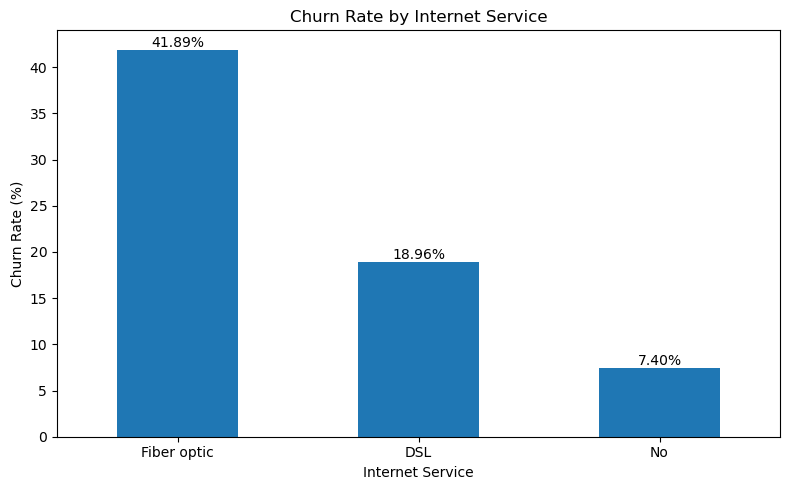

In [33]:
internet_churn_plot = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ax = internet_churn_plot.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### 10.4 Churn Rate by Customer Risk Score

This visual shows how observed churn increases as customers accumulate more of the five identified churn-associated characteristics.

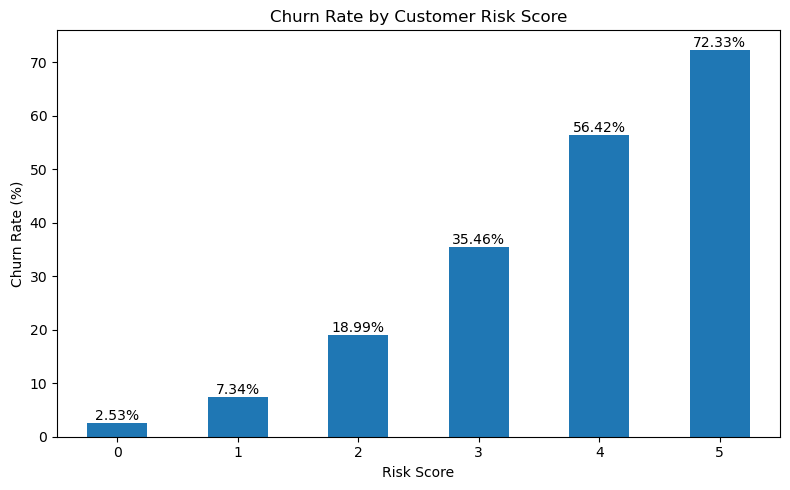

In [34]:
ax = risk_analysis.plot(
    x="risk_score",
    y="Churn_Rate",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Churn Rate by Customer Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Visualisation Summary

The visualisations highlight several important churn patterns. Churn is substantially higher among month-to-month customers, customers in their first year, and fiber optic customers.

The strongest pattern appears in the exploratory risk segmentation, where churn increases consistently as customers accumulate more churn-associated characteristics, rising from 2.53% among customers with a risk score of 0 to 72.33% among customers with a risk score of 5.

## 11. Key Business Insights

The customer churn analysis identified several important patterns that can help the company better understand which customer segments experience higher churn.

### 1. Overall Customer Churn

The overall churn rate is **26.54%**, with 1,869 of the 7,043 customers leaving the company. This means approximately one in four customers in the dataset churned.

### 2. Month-to-Month Customers Have Substantially Higher Churn

Customers on month-to-month contracts have a churn rate of **42.71%**, compared with **11.27%** for one-year contracts and only **2.83%** for two-year contracts.

This identifies month-to-month customers as an important segment for retention efforts.

### 3. Churn Is Highest During the First Year

Customers with 0–12 months of tenure have a churn rate of **47.44%**. Churn decreases as customer tenure increases, reaching just **9.51%** among customers with 49–72 months of tenure.

This suggests that the early customer lifecycle is a particularly important period for customer retention.

### 4. Fiber Optic Customers Have Higher Churn

Fiber optic customers have a churn rate of **41.89%**, compared with **18.96%** for DSL customers and **7.40%** for customers without internet service.

Fiber optic customers also have the highest average monthly charge at **$91.50**, suggesting that the customer experience, pricing and perceived value of this service should be investigated further.

### 5. Customers Without Tech Support Have Higher Churn

Among customers using internet services, customers without tech support have a churn rate of **41.64%**, compared with **15.17%** among customers with tech support.

This indicates that tech-support availability is associated with stronger customer retention, although the analysis does not establish a causal relationship.

### 6. Electronic-Check Customers Are a High-Churn Segment

Customers paying by electronic check have the highest churn rate among payment methods at **45.29%**. This compares with **16.71%** for automatic bank transfers and **15.24%** for automatic credit-card payments.

The electronic-check segment should be investigated further to determine whether other characteristics, such as contract type or tenure, contribute to its higher churn.

### 7. Month-to-Month Customers Without Tech Support Are Particularly High Risk

The combination of contract type and tech support identified a particularly important customer segment. Among **2,680 month-to-month customers without tech support, 1,350 churned**, resulting in a churn rate of **50.37%**.

This segment represents both a relatively large customer group and a high observed churn rate, making it a strong candidate for targeted retention analysis.

### 8. Multiple Risk Characteristics Provide Stronger Customer Segmentation

The exploratory risk score revealed a clear increase in churn as customers accumulated more churn-associated characteristics.

Customers with a risk score of **0** had an observed churn rate of only **2.53%**, while customers with all five identified risk characteristics had a churn rate of **72.33%**.

This suggests that combining multiple customer characteristics can provide a more useful approach to identifying high-risk customer segments than considering individual characteristics in isolation.

## 12. Business Recommendations

Based on the findings from the customer churn analysis, the following actions could be considered to support customer retention.

### 1. Prioritise New and Month-to-Month Customers

Customers within their first 12 months have a churn rate of **47.44%**, while month-to-month customers have a churn rate of **42.71%**.

The company should prioritise these customers for early retention initiatives. This could include improved onboarding, regular service check-ins, personalised offers and suitable incentives for customers who may benefit from longer-term contracts.

### 2. Investigate the Fiber Optic Customer Experience

Fiber optic customers have a churn rate of **41.89%** and the highest average monthly charge at **$91.50**.

The company should investigate this segment further to understand whether factors such as pricing, service quality, reliability, customer expectations or perceived value are contributing to the higher churn observed among fiber optic customers.

### 3. Test Initiatives to Increase Tech Support Adoption

Customers without tech support have a churn rate of **41.64%**, compared with **15.17%** among customers with tech support.

The company could test initiatives that make technical support more accessible or attractive to customers, particularly those on month-to-month contracts. The impact of these initiatives should be measured before concluding that tech support itself reduces churn.

### 4. Investigate Electronic-Check Customers

Customers using electronic checks have the highest churn rate among payment methods at **45.29%**, compared with **16.71%** for automatic bank transfers and **15.24%** for automatic credit-card payments.

The company should investigate why electronic-check customers experience higher churn and determine whether factors such as contract type, tenure, monthly charges or service selection explain part of this relationship. Where appropriate, customers could also be offered convenient automatic payment alternatives.

### 5. Focus Retention Efforts on High-Risk Customer Segments

Month-to-month customers without tech support represent a particularly important segment, with **1,350 of 2,680 customers churning**, resulting in a churn rate of **50.37%**.

The exploratory risk score also shows that churn increases as customers accumulate multiple churn-associated characteristics, from **2.53%** among customers with a risk score of 0 to **72.33%** among customers with a score of 5.

The company could use these characteristics as an initial segmentation framework to prioritise customers for retention campaigns. However, the risk score should be validated on unseen data before being used as a predictive decision-making tool.

## 13. Conclusion

This project analysed customer churn across 7,043 telecommunications customers to identify the characteristics associated with customers leaving the company. The overall churn rate was **26.54%**, meaning approximately one in four customers in the dataset had churned.

The analysis identified several customer segments with substantially higher churn. Month-to-month customers had a churn rate of **42.71%**, while customers within their first 12 months had the highest tenure-based churn rate at **47.44%**. Fiber optic customers recorded a churn rate of **41.89%** and also had the highest average monthly charge at **$91.50**. Customers without tech support had a churn rate of **41.64%**, while customers paying by electronic check had a churn rate of **45.29%**.

Combining customer characteristics revealed additional insights. Month-to-month customers without tech support represented a particularly high-risk segment, with **1,350 of 2,680 customers churning**, resulting in a churn rate of **50.37%**.

An exploratory customer risk score was also developed using five churn-associated characteristics: month-to-month contracts, tenure of 12 months or less, fiber optic internet service, no tech support and electronic-check payment. Observed churn increased from **2.53%** among customers with a risk score of 0 to **72.33%** among customers with all five risk characteristics.

Based on these findings, the company could prioritise retention efforts toward newer and month-to-month customers, investigate the customer experience and value proposition of fiber optic services, test initiatives to increase access to tech support, and further investigate the high churn observed among electronic-check customers.

The relationships identified in this analysis represent associations rather than proof of causation. In addition, the exploratory risk score was developed and evaluated using the same dataset and should therefore be validated on unseen data before being used as a predictive decision-making tool.

Overall, the analysis demonstrates how customer data can be transformed into actionable business insights that support customer segmentation and more targeted retention strategies.